Modelo Juan Felipe Echeverry

# Modelo de Regresión — Predicción de Puntaje Global Saber 11

**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Juan Felipe Echeverry  
**Rol:** Ciencia de Datos  

## Contexto

Este notebook desarrolla un modelo predictivo de regresión basado en redes neuronales para estimar el **puntaje global** que un estudiante obtendría en la prueba Saber 11, a partir de sus características socioeconómicas, demográficas y del colegio en el que estudia.

**Usuario final:** Secretaría de Educación de Bolívar.

**Pregunta de negocio:** ¿Qué factores socioeconómicos, demográficos y del entorno escolar permiten predecir el puntaje global Saber 11 de los estudiantes de Bolívar, y cómo puede la Secretaría de Educación estimar el puntaje esperado de distintos perfiles de estudiante para focalizar programas de refuerzo académico en las poblaciones con mayor riesgo de bajo desempeño?

## 1. Carga de datos limpios

Cargamos el dataframe ya procesado por el script de limpieza `Proyecto2.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('DatosSaber11_Bolivar_limpio_todas_columnas.csv')
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()
df.dtypes

Filas: 122,866
Columnas: 52


estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object
cole_cod_dane_es

## 2. Exploración del target: `punt_global`

El `punt_global` es nuestra variable objetivo. Está en escala 0–500 (suma ponderada de las áreas evaluadas). Revisamos su distribución antes de modelar.

In [3]:
df['punt_global'].describe()

count    122866.000000
mean        236.134561
std          48.642475
min           0.000000
25%         200.000000
50%         229.000000
75%         266.000000
max         475.000000
Name: punt_global, dtype: float64

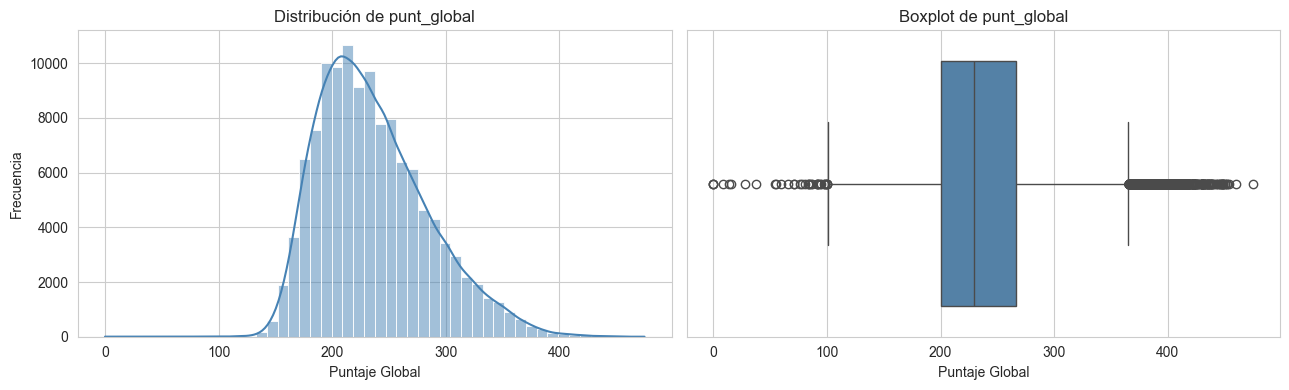

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
sns.histplot(df['punt_global'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de punt_global')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df['punt_global'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de punt_global')
axes[1].set_xlabel('Puntaje Global')

plt.tight_layout()
plt.show()